# 5350-flex Model Validation & Comparison to 5350
## Setup

In [1]:
import importlib
import logging
import pathlib
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from use_core import constants, run_info, task

sys.path.insert(0, "..")
build_models = importlib.import_module("build-models")

sns.set()

run_info.logger.setLevel(logging.CRITICAL)

In [2]:
class MockRunConfig:
    def __init__(
        self,
        dedup_ratio: float,
        kb_transferred: int,
        num_streams: int,
        task: str,
        workload_type: str,
        io_duplex: task.TaskDuplexType,
    ) -> None:
        self.dedup_ratio = dedup_ratio
        self.kb_transferred = kb_transferred
        self.num_streams = num_streams
        self.task = task
        self.workload_type = workload_type
        self.io_duplex = io_duplex

class MockApplianceConfig:
    def __init__(
        self,
        appliance: str,
        site_version: str,
        memory: int,
        number_of_total_drives: int,
    ) -> None:
        self.appliance = appliance
        self.site_version = site_version
        self.memory = memory
        self.number_of_total_drives = number_of_total_drives

## Reading in Data

In [3]:
root_data_dir = pathlib.Path("../data")
data_dir_5350 = root_data_dir / "5350/9.0/default"
data_dir_5350_flex = root_data_dir / "5350-FLEX/9.0/default"

In [4]:
df_5350 = build_models.get_cpu_data(data_dir_5350, "backup", "default", "5350")
df_5350_flex = build_models.get_cpu_data(data_dir_5350_flex, "backup", "default", "5350-FLEX")

## Default Workload

In [5]:
appliance_config = MockApplianceConfig("5350", constants.SoftwareVersion.VER9_0, 256 * 1024 * 1024, 4)

actual_5350 = []
predicted_5350 = []

for row in df_5350.iterrows():
    record = row[1]
    actual_5350.append(record["cpu_usage_secs"])

    run_config = MockRunConfig(record["dedup_ratio"], record["kb_transferred"], record["num_streams"], "backup", "default", task.TaskDuplexType.half)
    ri = run_info.RunInfo(run_config, appliance_config)
    predicted_5350.append(ri.cpu_usage())



appliance_config = MockApplianceConfig("5350-FLEX", constants.SoftwareVersion.VER9_0, 256 * 1024 * 1024, 4)

actual_5350_flex = []
predicted_5350_flex = []

for row in df_5350_flex.iterrows():
    record = row[1]
    actual_5350_flex.append(record["cpu_usage_secs"])

    run_config = MockRunConfig(record["dedup_ratio"], record["kb_transferred"], record["num_streams"], "backup", "default", task.TaskDuplexType.half)
    ri = run_info.RunInfo(run_config, appliance_config)
    predicted_5350_flex.append(ri.cpu_usage())

df_5350_flex["predicted"] = predicted_5350_flex
df_5350_flex["diff"] = df_5350_flex["predicted"] - df_5350_flex["cpu_usage_secs"]

In [6]:
df_5350_flex[["dedup_ratio", "num_streams", "kb_transferred", "swapout", "cpu_usage_secs", "diff"]]

,dedup_ratio,num_streams,kb_transferred,swapout,cpu_usage_secs,diff
0,0.00,1,40980,0,6.016667,-0.016667
1,0.00,4,163920,0,15.139200,5.860800
2,0.00,8,327840,0,29.528571,12.471429
3,0.00,16,655680,0,59.683404,24.316596
4,0.00,32,1311361,0,102.016744,64.983256
5,0.00,64,2622722,0,271.777329,61.222671
6,0.00,96,3934083,1658,502.950985,-2.950985
7,0.00,128,5245444,2957,743.793723,-77.793723
8,0.00,192,7868166,6543,1180.278924,-181.278924
9,0.50,1,40980,0,5.111765,-1.111765


In [7]:
ri.cpu_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:         cpu_usage_secs   R-squared (uncentered):                   0.992
Model:                            OLS   Adj. R-squared (uncentered):              0.992
Method:                 Least Squares   F-statistic:                              1435.
Date:                Thu, 06 May 2021   Prob (F-statistic):                    5.12e-35
Time:                        17:44:58   Log-Likelihood:                         -175.33
No. Observations:                  36   AIC:                                      356.7
Df Residuals:                      33   BIC:                                      361.4
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
==============================================================================================
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
kb_transferred                 0.0001    6.5e-06     19.533      0.000       0.000       0.000
kb_transferred:dedup_ratio -6.396e-05      8e-06     -7.998      0.000   -8.02e-05   -4.77e-05
swapout                        0.0296      0.010      2.930      0.006       0.009       0.050
==============================================================================
Omnibus:                       18.110   Durbin-Watson:                   0.754
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               30.917
Skew:                           1.214   Prob(JB):                     1.93e-07
Kurtosis:                       6.836   Cond. No.                     7.63e+03
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[3] The condition number is large, 7.63e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

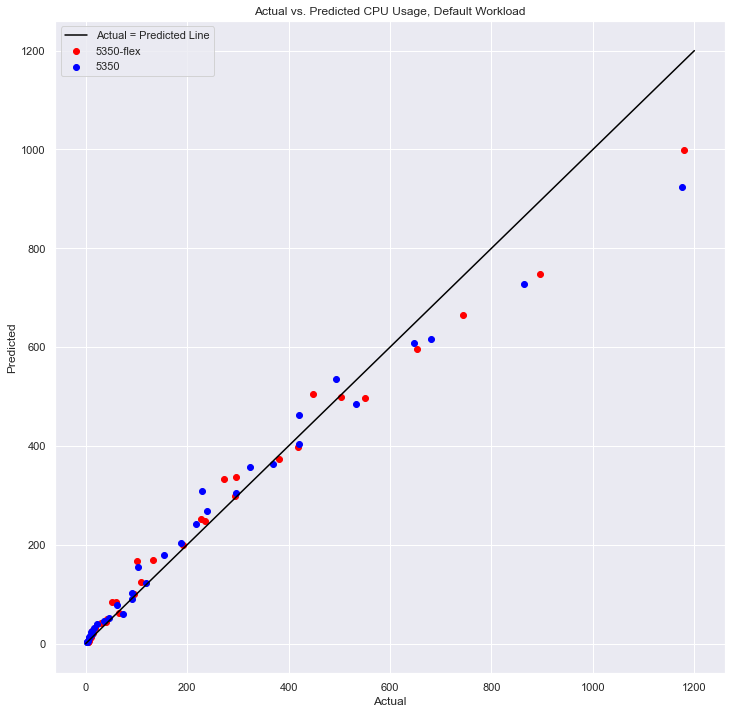

In [8]:
_, ax = plt.subplots(figsize=(12, 12))
ax.plot([0, 1200], [0, 1200], color="black", label="Actual = Predicted Line")

ax.scatter(actual_5350_flex, predicted_5350_flex, color="red", label="5350-FLEX")
ax.scatter(actual_5350, predicted_5350, color="blue", label="5350")

ax.legend()
ax.set(title="Actual vs. Predicted CPU Usage, Default Workload", xlabel="Actual", ylabel="Predicted");

## Comparison

In [9]:
appliance_config_5350 = MockApplianceConfig("5350", constants.SoftwareVersion.VER9_0, 256 * 1024 * 1024, 4)

appliance_config_5350_flex = MockApplianceConfig("5350-FLEX", constants.SoftwareVersion.VER9_0, 256 * 1024 * 1024, 4)

vals_5350 = []
vals_5350_flex = []

for row in df_5350.iterrows():
    record = row[1]
    vals_5350.append(record["cpu_usage_secs"])

    run_config = MockRunConfig(record["dedup_ratio"], record["kb_transferred"], record["num_streams"], "backup", "default", io_duplex=task.TaskDuplexType.half)
    ri = run_info.RunInfo(run_config, appliance_config)
    vals_5350_flex.append(ri.cpu_usage())

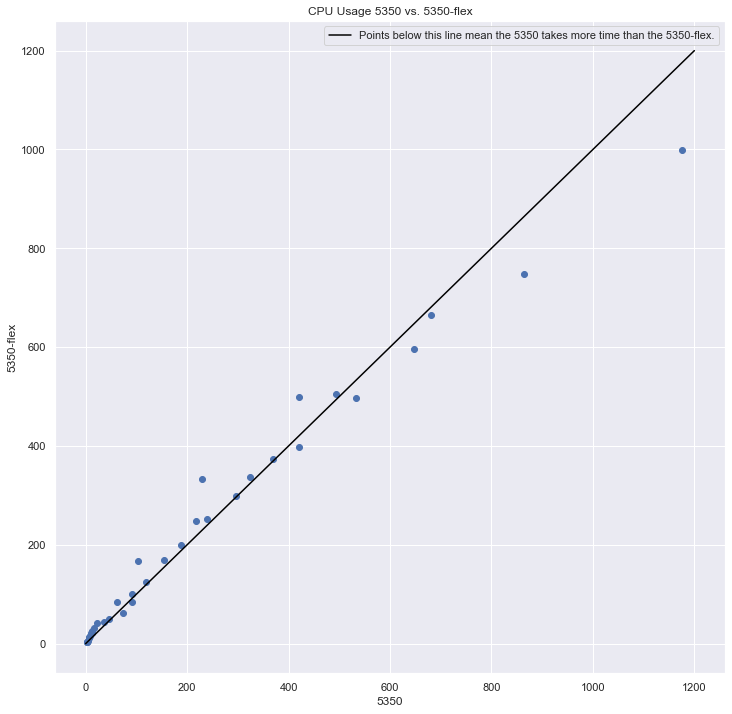

In [10]:
fig, ax = plt.subplots(figsize=(12, 12))
ax.scatter(vals_5350, vals_5350_flex)
ax.plot([0, 1200], [0, 1200], color="black", label="Points below this line mean the 5350 takes more time than the 5350-FLEX.")
ax.legend()
ax.set(title="CPU Usage 5350 vs. 5350-FLEX", xlabel="5350", ylabel="5350-FLEX");